## Exploratory Data Analysis: The Arsenal Story


---
## Step 1 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
%matplotlib inline

#Plot Style
sns.set_theme(style = 'whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Colour Pallettes
ARSENAL_RED   = '#EF0107'
ARSENAL_NAVY  = '#063672'
ARSENAL_GOLD  = '#9C824A'
LIGHT_GREY    = '#D3D3D3'

STAKES_PALETTE = {'High Stakes' : ARSENAL_RED, 'Normal':ARSENAL_GOLD}

print('✅ All imports and style settings loaded')

✅ All imports and style settings loaded


---
##  Load Data

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROC_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

# Main Arsenal Dataset
ars = pd.read_csv(PROC_DATA_DIR / 'arsenal_processed.csv')
ars['date'] = pd.to_datetime(ars['date'])
ars= ars.sort_values('date').reset_index(drop = True)

# Pre arteta baseline
pre = pd.read_csv(RAW_DATA_DIR / 'arsenal_pre_arteta_raw.csv')
pre['date'] = pd.to_datetime(pre['date'])
pre = pre.sort_values('date').reset_index(drop = True)

# Drop Index summary table
drop_idx = pd.read_csv(PROC_DATA_DIR / 'drop_index.csv', index_col = 0)

print(f'Arsenal (Arteta era) : {ars.shape}')
print(f'Arsenal (pre-Arteta) : {pre.shape}')
print(f'Drop Index table     : {drop_idx.shape}')
print(f'\nArteta seasons : {sorted(ars["season"].unique())}')
print(f'Pre-Arteta     : {sorted(pre["season"].unique())}')

Arsenal (Arteta era) : (266, 37)
Arsenal (pre-Arteta) : (76, 11)
Drop Index table     : (4, 14)

Arteta seasons : [np.int64(1920), np.int64(2021), np.int64(2122), np.int64(2223), np.int64(2324), np.int64(2425), np.int64(2526)]
Pre-Arteta     : [np.int64(1718), np.int64(1819)]


---
## Quick Data Overview

In [3]:
#Match count per season
print("Matches per season: ")
print(ars.groupby('season').size())
print(f'\nTotal: {len(ars)} matches')
print(f'High stakes (live, threshold-based):     {ars["is_high_stakes"].sum()} ({ars["is_high_stakes"].mean()*100:.1f}%)')
print(f'High stakes (retro, top 25% per season): {ars["is_high_stakes_retro"].sum()} ({ars["is_high_stakes_retro"].mean()*100:.1f}%)')
print(f'Normal (retro):                          {(~ars["is_high_stakes_retro"]).sum()} ({(~ars["is_high_stakes_retro"]).mean()*100:.1f}%)')
print()
print("Section C uses is_high_stakes_retro throughout — it's calibrated to give every")
print("season a comparable proportion of truly high-pressure matches. is_high_stakes")
print("(the looser, absolute-threshold version) stays reserved for live/ML use in")
print("NB06-07, where the season-relative version would leak future information.")

Matches per season: 
season
1920    38
2021    38
2122    38
2223    38
2324    38
2425    38
2526    38
dtype: int64

Total: 266 matches
High stakes (live, threshold-based):     74 (27.8%)
High stakes (retro, top 25% per season): 70 (26.3%)
Normal (retro):                          196 (73.7%)

Section C uses is_high_stakes_retro throughout — it's calibrated to give every
season a comparable proportion of truly high-pressure matches. is_high_stakes
(the looser, absolute-threshold version) stays reserved for live/ML use in
NB06-07, where the season-relative version would leak future information.


In [4]:
# ── Compute per-match Drop Index ──────────────────────────────────────────────
# The drop_index.csv has the TEAM-LEVEL aggregate.
# For scatter/heatmap charts we need a PER-MATCH version:
#   match_drop = (season_avg_xG - match_xG + match_xGA - season_avg_xGA) / 2
# Positive = underperformed vs season average. Negative = overperformed.

season_xg_avg  = ars.groupby('season')['xG'].transform('mean')
season_xga_avg = ars.groupby('season')['xGA'].transform('mean')

ars['match_drop_index'] = (
    (season_xg_avg - ars['xG']) + (ars['xGA'] - season_xga_avg)
) / 2

# Readable label for stakes — uses the retrospective (season-relative top 25%) flag
ars['stake_label'] = ars['is_high_stakes_retro'].map({True: 'High Stakes', False: 'Normal'})

print(f'Match Drop Index — mean: {ars["match_drop_index"].mean():.4f}  '
      f'(should be ~0, it\'s a deviation from average)')
print(f'Range: {ars["match_drop_index"].min():.3f} to {ars["match_drop_index"].max():.3f}')

Match Drop Index — mean: 0.0000  (should be ~0, it's a deviation from average)
Range: -2.416 to 2.375


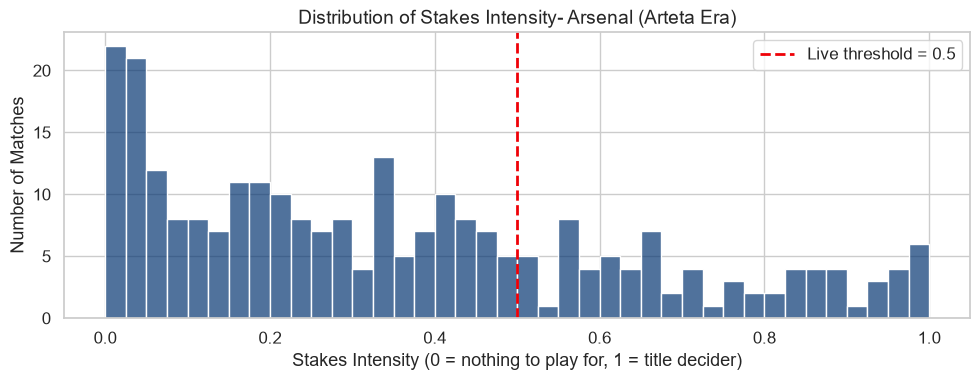

Note: the line above is the absolute 'live' threshold (is_high_stakes), shown
here because it's a single fixed cutoff. Section C's charts instead use
is_high_stakes_retro — the top 25% of stakes_intensity WITHIN each season —
which doesn't correspond to one fixed x-value on this plot.


In [5]:
#Stakes intensity distribution

fig, ax = plt.subplots(figsize = (10, 4))

sns.histplot(data=ars, x = 'stakes_intensity',bins = 40, color= ARSENAL_NAVY, alpha = 0.7, ax = ax)

ax.axvline(x=0.5, color = ARSENAL_RED, linestyle='--', linewidth = 2, label = 'Live threshold = 0.5')

ax.set_title('Distribution of Stakes Intensity- Arsenal (Arteta Era)',fontsize = 14)
ax.set_xlabel('Stakes Intensity (0 = nothing to play for, 1 = title decider)')
ax.set_ylabel('Number of Matches')
ax.legend()

plt.tight_layout()
plt.show()

print("Note: the line above is the absolute 'live' threshold (is_high_stakes), shown")
print("here because it's a single fixed cutoff. Section C's charts instead use")
print("is_high_stakes_retro — the top 25% of stakes_intensity WITHIN each season —")
print("which doesn't correspond to one fixed x-value on this plot.")

In [6]:
#High stakes count per season- check the split makes sense (retro flag)

stakes_by_season = (
    ars.groupby('season')['is_high_stakes_retro']
    .agg(['sum','count'])
    .rename(columns={'sum': 'high_stakes','count':'total'})
)
stakes_by_season['normal'] = stakes_by_season['total'] - stakes_by_season['high_stakes']
stakes_by_season['pct_high'] = (stakes_by_season['high_stakes'] / stakes_by_season['total'] * 100).round(1)

print('High-stakes matches per season (retro, top 25% per season): ')
print(stakes_by_season)

High-stakes matches per season (retro, top 25% per season): 
        high_stakes  total  normal  pct_high
season                                      
1920             10     38      28      26.3
2021             10     38      28      26.3
2122             10     38      28      26.3
2223             10     38      28      26.3
2324             10     38      28      26.3
2425             10     38      28      26.3
2526             10     38      28      26.3


---
## SECTION A - Pre-Arteta Baseline (2017-19)

---
## Chart A1 - "The Starting Point"

Pre-Arteta Averages:  {'xG': np.float64(1.803), 'xGA': np.float64(1.395), 'xGD': np.float64(0.408)}
Arteta era Averages:  {'xG': np.float64(1.799), 'xGA': np.float64(1.124), 'xGD': np.float64(0.675)}


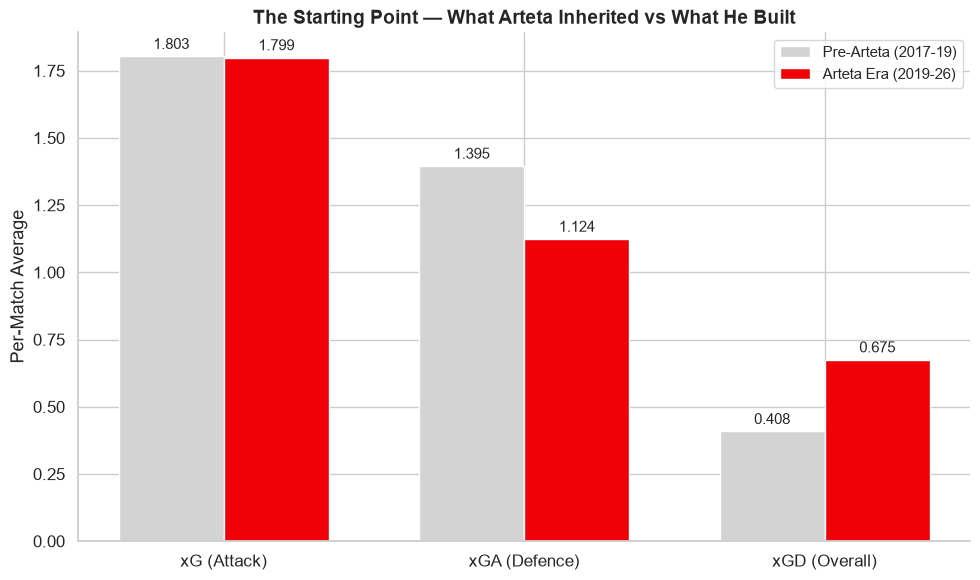

In [7]:
#Compute era averages
pre_avg = {
    'xG' : pre['xG'].mean(),
    'xGA': pre['xGA'].mean(),
    'xGD' : (pre['xG'] - pre['xGA']).mean()
}
arteta_avg = {
    'xG' : ars['xG'].mean(),
    'xGA' : ars['xGA'].mean(),
    'xGD' : ars['xgd'].mean()
}

print('Pre-Arteta Averages: ', {k: round(v,3) for k, v in pre_avg.items()})
print('Arteta era Averages: ', {k: round(v,3) for k,v in arteta_avg.items()})

#Chart A1
labels = ['xG (Attack)', 'xGA (Defence)', 'xGD (Overall)']
pre_vals = [pre_avg['xG'], pre_avg['xGA'], pre_avg['xGD']]
arteta_vals = [arteta_avg['xG'], arteta_avg['xGA'], arteta_avg['xGD']]

x = np.arange(len(labels))
width = 0.35

fix, ax = plt.subplots(figsize=(10,6))

bars1 = ax.bar(x - width/2, pre_vals, width, label = 'Pre-Arteta (2017-19)',
              color = LIGHT_GREY, edgecolor = 'white')
bars2 = ax.bar(x + width/2, arteta_vals, width, label = 'Arteta Era (2019-26)',
              color = ARSENAL_RED, edgecolor = 'white')

ax.bar_label(bars1, fmt = '%.3f', padding = 3, fontsize = 11)
ax.bar_label(bars2, fmt = '%.3f', padding = 3, fontsize = 11)

ax.axhline(y=0,color='grey',linewidth = 0.8,linestyle = '-')
ax.set_ylabel('Per-Match Average')
ax.set_title('The Starting Point — What Arteta Inherited vs What He Built',
             fontsize=14, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## Section B - The Rise (2019-22)

---
## Chart B1 - Season-by-Season xG and xGA Trends

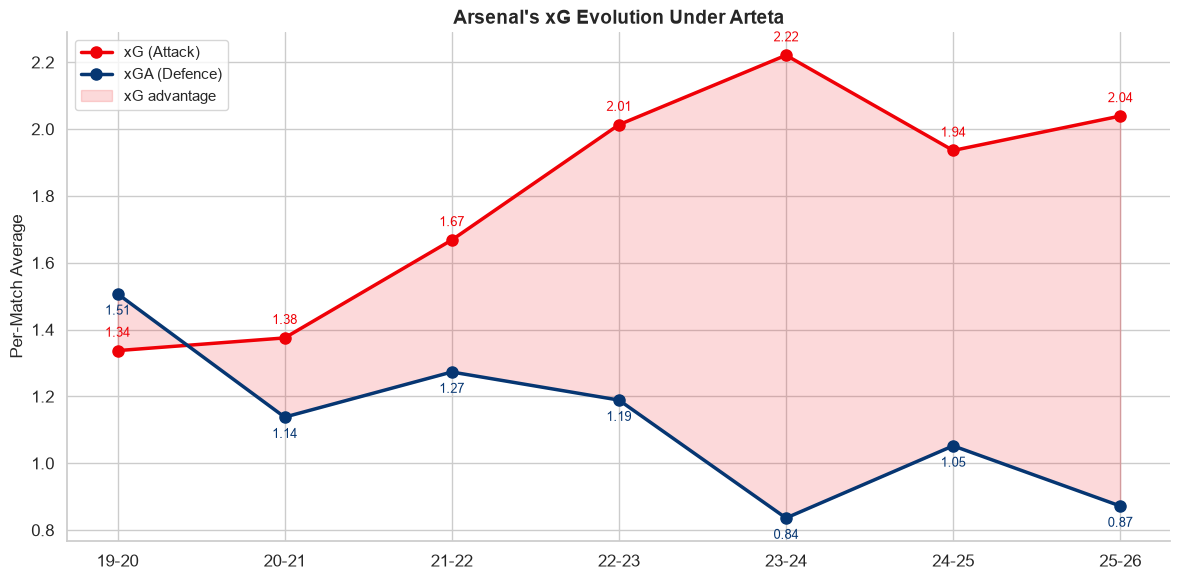


Season averages:
           xG    xGA
season              
1920    1.337  1.507
2021    1.375  1.138
2122    1.668  1.273
2223    2.013  1.189
2324    2.221  0.836
2425    1.936  1.052
2526    2.039  0.872


In [8]:
# Season Averages
season_avg = (
    ars.groupby('season')[['xG','xGA']]
    .mean().round(3)
)

# Season Labels for x- axis
SEASON_LABELS = {
    1920: '19-20', 2021: '20-21', 2122: '21-22',
    2223: '22-23', 2324: '23-24', 2425: '24-25', 2526: '25-26'
}
season_avg['label'] = season_avg.index.map(SEASON_LABELS)

# Chart B1
fig, ax = plt.subplots(figsize = (12,6))

x_pos = range(len(season_avg))

ax.plot(x_pos, season_avg['xG'], marker = 'o', linewidth = 2.5, markersize=8,
       color = ARSENAL_RED, label = 'xG (Attack)', zorder = 3)
ax.plot(x_pos, season_avg['xGA'], marker = 'o', linewidth = 2.5, markersize=8,
       color = ARSENAL_NAVY, label = 'xGA (Defence)', zorder = 3)

#Shade the gap bw xG and xGA
ax.fill_between(x_pos, season_avg['xG'],season_avg['xGA'],
               alpha = 0.15, color = ARSENAL_RED, label = 'xG advantage')

#Annotate values on eachpoint
for i,(xg,xga) in enumerate(zip(season_avg['xG'], season_avg['xGA'])):
    ax.annotate(f'{xg:.2f}', (i,xg), textcoords='offset points', xytext= (0,10),
               ha='center',fontsize = 9, color = ARSENAL_RED)
    ax.annotate(f'{xga:.2f}', (i,xga), textcoords = 'offset points', 
                xytext = (0,-15), ha = 'center', fontsize = 9, color = ARSENAL_NAVY)

ax.set_xticks(x_pos)
ax.set_xticklabels(season_avg['label'], fontsize = 12)
ax.set_ylabel('Per-Match Average', fontsize = 12)
ax.set_title("Arsenal's xG Evolution Under Arteta", fontsize = 14, fontweight='bold')
ax.legend(loc='upper left',fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('\nSeason averages:')
print(season_avg[['xG', 'xGA']].to_string())

---
## Chart B2 - Points per Game & Win Rate by Season

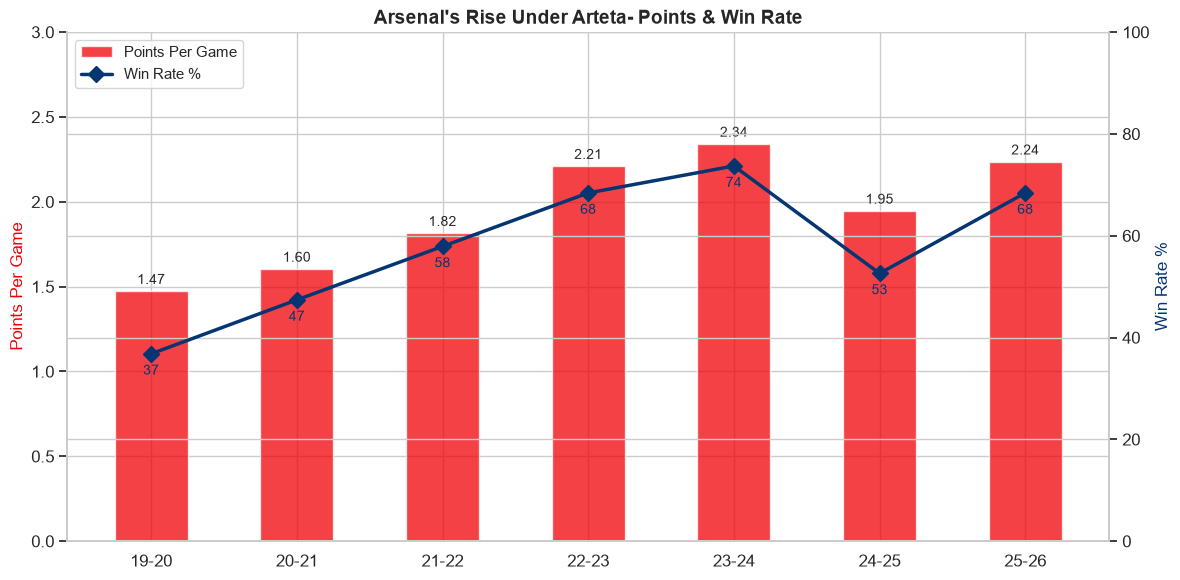


Season performance:
          ppg  win_rate_pct  total_pts
season                                
1920    1.474          36.8         56
2021    1.605          47.4         61
2122    1.816          57.9         69
2223    2.211          68.4         84
2324    2.342          73.7         89
2425    1.947          52.6         74
2526    2.237          68.4         85


In [9]:
#Compute PPG and win rate per season
season_perf = ars.groupby('season').agg(
    ppg = ('points', 'mean'),
    win_rate = ('is_win', 'mean'),
    total_pts = ('points', 'sum')
).round(3)
season_perf['win_rate_pct'] = (season_perf['win_rate']*100).round(2)
season_perf['label'] = season_perf.index.map(SEASON_LABELS)

#Chart B2
fix, ax1 = plt.subplots(figsize=(12,6))

x_pos = range(len(season_perf))

# Bars = PPG on left axis
bars = ax1.bar(x_pos, season_perf['ppg'], color = ARSENAL_RED, alpha = 0.75,
              width = 0.5, label = 'Points Per Game',zorder = 2)
ax1.bar_label(bars,fmt = '%.2f', padding = 3, fontsize = 10)
ax1.set_ylabel('Points Per Game', fontsize = 12, color = ARSENAL_RED)
ax1.set_ylim(0,3)

# Line = Win rate on right axis
ax2 = ax1.twinx()
ax2.plot(x_pos, season_perf['win_rate_pct'], marker = 'D', linewidth = 2.5,
        markersize = 8, color = ARSENAL_NAVY, label = "Win Rate %", zorder = 3)
ax2.set_ylabel('Win Rate %', fontsize = 12, color = ARSENAL_NAVY)
ax2.set_ylim(0,100)

#Annotate win rate values
for i, wr in enumerate(season_perf['win_rate_pct']) :
    ax2.annotate(f'{wr:.0f}', (i,wr), textcoords='offset points',
                xytext=(0,-15), ha='center',fontsize=10,color = ARSENAL_NAVY)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(season_perf['label'],fontsize=12)
ax1.set_title("Arsenal's Rise Under Arteta- Points & Win Rate",
             fontsize = 14, fontweight = 'bold')

#Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc = 'upper left', fontsize = 11)

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

print('\nSeason performance:')
print(season_perf[['ppg', 'win_rate_pct', 'total_pts']].to_string())

---
## Section C - The Three Bottles (2022-25)

---
## Chart C1 - Drop Index Scatter: All Arteta-Era Matches

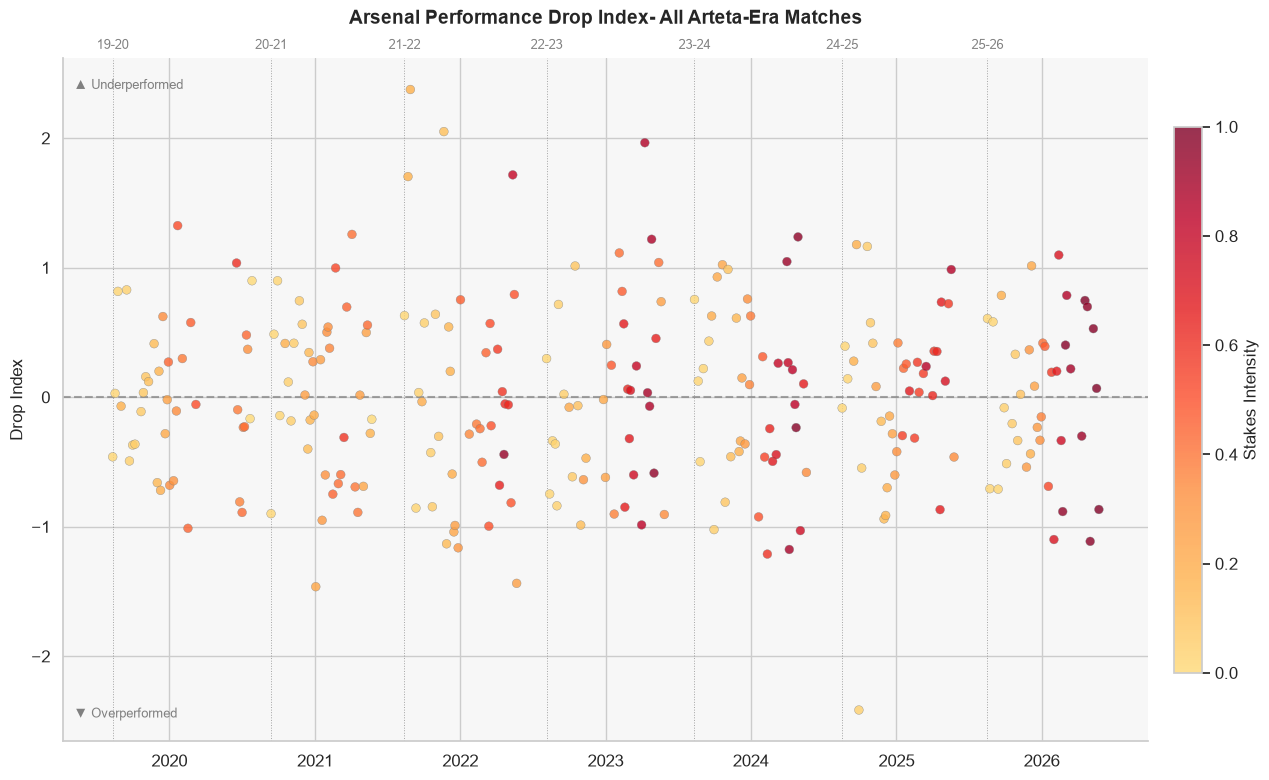

In [10]:
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# 1. Fetch the base colormap using the modern registry
base_cmap = mpl.colormaps['YlOrRd']

# 2. Slice the colormap array (skipping the first 25%)
truncated_colors = base_cmap(np.linspace(0.25, 1.0, 256))

# 3. Create the new truncated colormap
truncated_cmap = LinearSegmentedColormap.from_list(
    'YlOrRd_dark',
    truncated_colors
)

# Chart C1: Drop Index scatter over time
fig, ax = plt.subplots(figsize=(14,8))

ax.set_facecolor('#f7f7f7')
# Scatter with continuous colours = stakes_intensity
scatter = ax.scatter(
    ars['date'],ars['match_drop_index'],
    c=ars['stakes_intensity'],    # colour mapped to stakes
    cmap = truncated_cmap,
    s=40, alpha = 0.8, edgecolors = 'grey', linewidths=0.3, zorder = 3
)

# Ref line y=0
ax.axhline(y=0, color = 'grey', linewidth = 1.5, linestyle = '--', alpha = 0.7)

# Season boundary lines
season_starts = ars.groupby('season')['date'].min()
for season_code, start_date in season_starts.items() :
    ax.axvline(x = start_date, color = 'grey', linewidth = 0.7,
              linestyle = ':', alpha = 0.7)
    label = SEASON_LABELS.get(season_code,str(season_code))
    ax.annotate(label, xy=(start_date, 1), xycoords=('data', 'axes fraction'),
                xytext=(0, 5), textcoords='offset points',
                fontsize=9, color='grey', ha='center', va='bottom')

# Colourbar- gradient explanation
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8,pad=0.02)
cbar.set_label('Stakes Intensity',fontsize=12)

ax.set_title('Arsenal Performance Drop Index- All Arteta-Era Matches',
            fontsize=14, fontweight='bold',pad = 25)
ax.set_xlabel('')
ax.set_ylabel('Drop Index', fontsize=12)
ax.text(0.01, 0.97, '▲ Underperformed', transform=ax.transAxes,
        fontsize=9, color='grey', ha='left', va='top')
ax.text(0.01, 0.03, '▼ Overperformed', transform=ax.transAxes,
        fontsize=9, color='grey', ha='left', va='bottom')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## Chart C2 - Heatmap: Gameweek x Season Drop Index

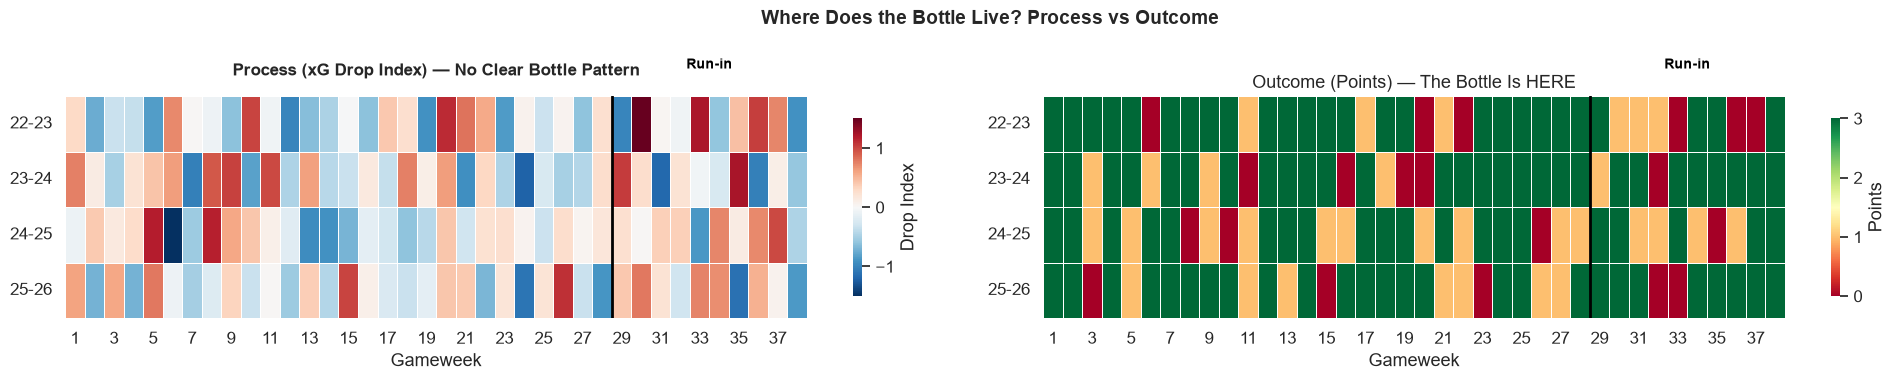

In [11]:
# Only contending seasons (22-23 onwards)
contending = ars[ars['season'].isin([2223,2324,2425,2526])]
contending['season_label'] = contending['season'].map(SEASON_LABELS)

row_order = ['22-23', '23-24', '24-25', '25-26']

# Left panel: xG Drop Index(Process)
heat_xg = contending.pivot_table(
    index = 'season_label', columns = 'gameweek', values = 'match_drop_index', aggfunc='mean'
).loc[row_order]

# Right panel: Points(Outcome)
heat_pts = contending.pivot_table(
    index = 'season_label',columns = 'gameweek', values = 'points', aggfunc = 'mean'
).loc[row_order]

# Side by side heatmaps
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(20,4))

#Left; xG Drop Index- Diverging (red=bad, blue = good)
sns.heatmap(heat_xg, cmap='RdBu_r',center=0,vmin=-1.5,vmax=1.5,
           linewidths=0.5,linecolor='white',
           cbar_kws={'label': 'Drop Index', 'shrink': 0.8},ax=ax1)
ax1.axvline(x=28,color='black',linewidth=2)
ax1.set_title('Process (xG Drop Index) — No Clear Bottle Pattern',
              fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Gameweek')
ax1.set_ylabel('')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)


# Right: Points - sequential (green = 3pts, red= 0pts)
sns.heatmap(heat_pts,cmap='RdYlGn',vmin=0,vmax=3,
           linewidths=0.5,linecolor='white',
           cbar_kws={'label': 'Points', 'shrink':0.8}, ax=ax2)
ax2.axvline(x=28, color='black', linewidth=2)
ax2.set_title('Outcome (Points) — The Bottle Is HERE')
ax2.set_xlabel('Gameweek')
ax2.set_ylabel('')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

# Run-in label above both panels
for a in (ax1,ax2):
    a.text(33,-0.5, 'Run-in', ha='center', fontsize=10,
           fontweight='bold',color='black')

fig.suptitle('Where Does the Bottle Live? Process vs Outcome',
             fontsize=14, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

### Reading the Two Heatmaps: Process vs. Outcome
* **Left (xG Drop Index — Process):** The run-in zone (GW29–38) shows no systemic collapse. Across all four seasons, it is a balanced mix of blue (overperforming) and pale red (underperforming). Arteta's underlying system remained stable under pressure—Arsenal consistently created and prevented chances at their typical rates.
* **Right (Points — Outcome):** The points tell a completely different, much harsher story:
  * **The True Bottles (`22-23` & `24-25`):** The run-in is heavily stained with yellow (draws) and red (losses). The collapse in results happened despite solid underlying metrics.
  * **The Outperformed Year (`23-24`):** The run-in is almost entirely green. Arsenal dropped points in just two high-stakes matches (City and Villa); they did not collapse, Manchester City was simply flawless.
  * **The Breakthrough (`25-26`):** Solid green across the run-in, mirroring their underlying xG strength to secure the title.
---
### 💡 Core Takeaway
> **The "bottle" does not live in chance creation (xG)—it lives in conversion and composure.**  
> Arsenal didn't play worse football in pressure moments; they simply failed to turn dominant metrics into actual goals and points during `22-23` and `24-25`.

In [12]:
# What does the run-in ACTUALLY look like by the numbers?
for szn in [2223, 2324, 2425, 2526]:
    runin = ars[(ars['season'] == szn) & (ars['gameweek'] >= 29)]
    hs_runin = runin[runin['is_high_stakes_retro']]
    
    print(f"\n{SEASON_LABELS[szn]}:")
    print(f"  Run-in matches: {len(runin)}, High-stakes in run-in: {len(hs_runin)}")
    print(f"  Run-in avg DI: {runin['match_drop_index'].mean():.3f}")
    print(f"  Run-in points: {runin['points'].sum()} / {len(runin)*3} possible")
    if len(hs_runin) > 0:
        print(f"  HS run-in losses/draws:")
        bad = hs_runin[hs_runin['result'] != 'W']
        print(bad[['gameweek','opponent','scored','conceded','result','match_drop_index']].to_string(index=False))


22-23:
  Run-in matches: 10, High-stakes in run-in: 6
  Run-in avg DI: 0.290
  Run-in points: 15 / 30 possible
  HS run-in losses/draws:
 gameweek        opponent  scored  conceded result  match_drop_index
       30       Liverpool       2         2      D          1.964391
       31        West Ham       2         2      D          0.034051
       32     Southampton       3         3      D         -0.070244
       33 Manchester City       1         4      L          1.219140

23-24:
  Run-in matches: 10, High-stakes in run-in: 8
  Run-in avg DI: -0.021
  Run-in points: 25 / 30 possible
  HS run-in losses/draws:
 gameweek        opponent  scored  conceded result  match_drop_index
       29 Manchester City       0         0      D          1.046585
       32     Aston Villa       0         2      L          0.211751

24-25:
  Run-in matches: 10, High-stakes in run-in: 9
  Run-in avg DI: 0.219
  Run-in points: 19 / 30 possible
  HS run-in losses/draws:
 gameweek       opponent  scored 

---
## Chart C4 - xG Distribution: High Stakes vs Normal (Violin Plot)

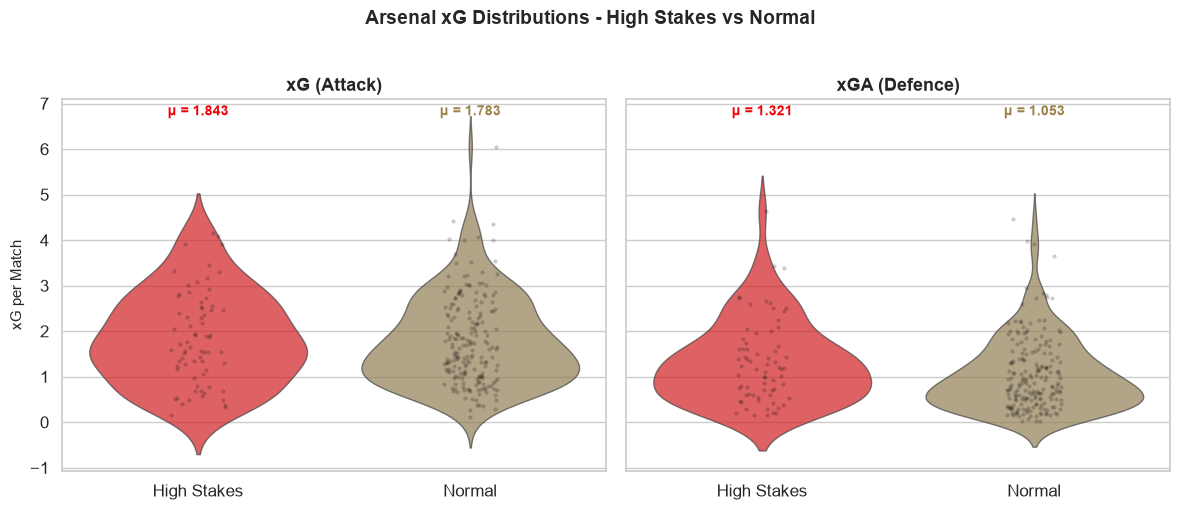

In [13]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize = (12,5), sharey=True)

# Left panel : xG (Attack)
sns.violinplot(data=ars, x= 'stake_label', y='xG', ax=ax1, 
               order = ['High Stakes','Normal'],
              palette=STAKES_PALETTE, alpha = 0.7, inner = None, linewidth=1)
sns.stripplot(data=ars, x='stake_label', y='xG',ax=ax1,
             order = ['High Stakes', 'Normal'],
             color = 'black', alpha = 0.2, size = 3, jitter = True)
ax1.set_title('xG (Attack)', fontsize = 13, fontweight = 'bold')
ax1.set_xlabel('')
ax1.set_ylabel('xG per Match', fontsize = 11)

# Right panel: xGA (Defence)
sns.violinplot(data=ars, x= 'stake_label',y='xGA', ax=ax2,
              order = ['High Stakes','Normal'],
              palette=STAKES_PALETTE, alpha = 0.7, inner = None, linewidth=1)
sns.stripplot(data=ars, x='stake_label', y='xGA', ax=ax2, order=['High Stakes', 'Normal'],
              color='black', alpha=0.2, size=3, jitter=True)
ax2.set_title('xGA (Defence)', fontsize=13, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('xGA per Match', fontsize = 11)

# Add mean annotations
for ax_panel, col in [(ax1, 'xG'), (ax2, 'xGA')]:
    for i, label in enumerate(['High Stakes', 'Normal']):
        mean_val = ars[ars['stake_label'] == label][col].mean()
        ax_panel.text(i, ax_panel.get_ylim()[1] * 0.95, f'μ = {mean_val:.3f}',
                      ha='center', fontsize=10, fontweight='bold',
                      color=ARSENAL_RED if label == 'High Stakes' else ARSENAL_GOLD)

        fig.suptitle('Arsenal xG Distributions - High Stakes vs Normal',
                    fontsize = 14, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.show()

---
## Chart C5 - The Bottle Gap: High-Stakes PPG vs Season-Baseline PPG

In [14]:
# Compute high-stakes PPG vs season-baseline PPG per season
#
# Why PPG and not xGD/GD: goal difference is continuous and gets dominated by
# blowout wins sitting in the same high-stakes bucket as a costly draw — a 6-0
# masks what a 2-2 actually cost. Points (win=3/draw=1/loss=0) are the currency
# that Charts C2/C3 already use, and they capture the "should have won, only
# drew" pain directly instead of averaging it away.
seasons = [2223, 2324, 2425, 2526]
labels_list = [SEASON_LABELS[s] for s in seasons]

hs_ppg_vals     = [ars[(ars['season']==s) & (ars['is_high_stakes_retro'])]['points'].mean() for s in seasons]
season_ppg_vals = [ars[ars['season']==s]['points'].mean() for s in seasons]
n_high_vals     = [ars[(ars['season']==s) & (ars['is_high_stakes_retro'])].shape[0] for s in seasons]

print("High-Stakes PPG vs Season-Baseline PPG: ")
for lbl, hs, base, n in zip(labels_list, hs_ppg_vals, season_ppg_vals, n_high_vals):
    diff = hs - base
    print(f'  {lbl}: high_stakes_ppg={hs:+.2f}  season_ppg={base:+.2f}  diff={diff:+.2f}  (n={n})')

print()
print("Caveat: n=10/season is small, opponent difficulty isn't controlled for,")
print("and these diffs haven't been through a significance test — see NB05 before")
print("treating this as more than directional evidence.")

High-Stakes PPG vs Season-Baseline PPG: 
  22-23: high_stakes_ppg=+2.10  season_ppg=+2.21  diff=-0.11  (n=10)
  23-24: high_stakes_ppg=+2.50  season_ppg=+2.34  diff=+0.16  (n=10)
  24-25: high_stakes_ppg=+1.90  season_ppg=+1.95  diff=-0.05  (n=10)
  25-26: high_stakes_ppg=+2.40  season_ppg=+2.24  diff=+0.16  (n=10)

Caveat: n=10/season is small, opponent difficulty isn't controlled for,
and these diffs haven't been through a significance test — see NB05 before
treating this as more than directional evidence.


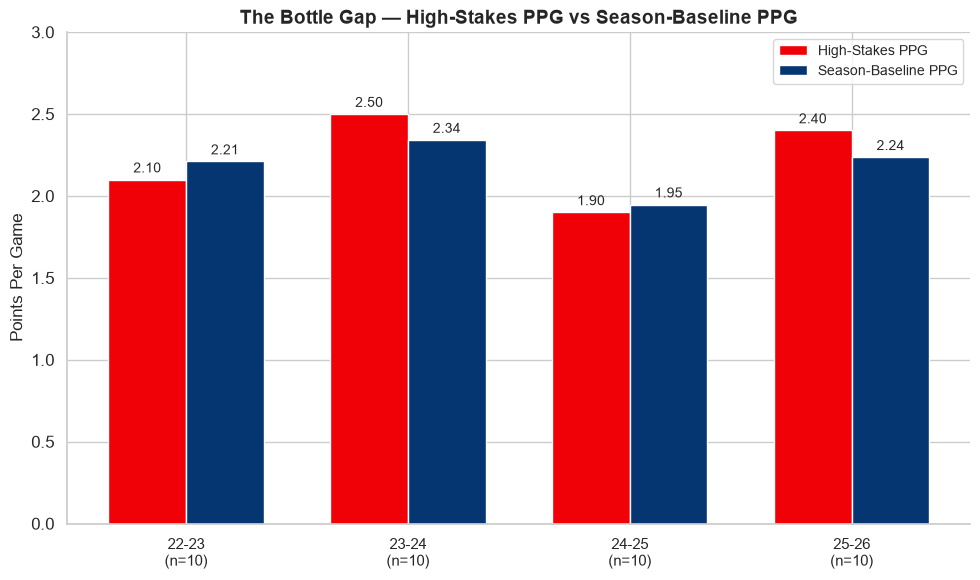

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(seasons))
width = 0.35

bars1 = ax.bar(x - width/2, hs_ppg_vals, width,
               label='High-Stakes PPG',
               color=ARSENAL_RED)
bars2 = ax.bar(x + width/2, season_ppg_vals, width,
               label='Season-Baseline PPG',
               color=ARSENAL_NAVY)

ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=10)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([f'{l}\n(n={n})' for l, n in zip(labels_list, n_high_vals)], fontsize=11)
ax.set_ylabel('Points Per Game', fontsize=12)
ax.set_ylim(0, 3)
ax.set_title('The Bottle Gap — High-Stakes PPG vs Season-Baseline PPG',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## Chart C6- Win Rate by Season: High Stakes vs Normal

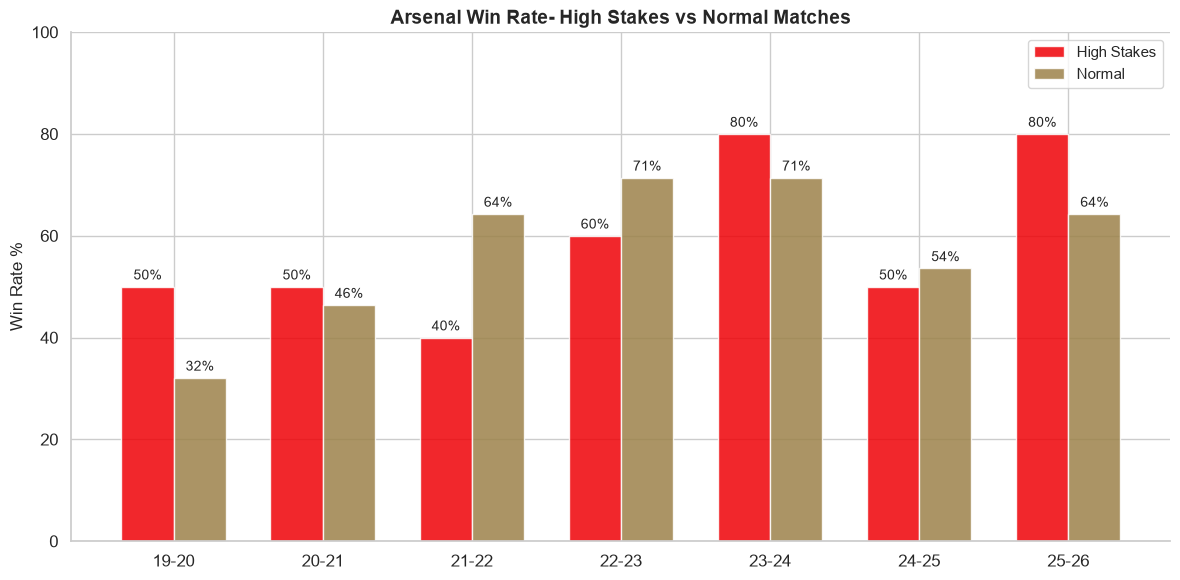

In [30]:
win_rates = (
    ars.groupby(['season','stake_label'])['is_win']
    .mean()
    .mul(100)
    .round(1)
    .unstack('stake_label')
)
win_rates['label'] = win_rates.index.map(SEASON_LABELS)

fig, ax = plt.subplots(figsize = (12,6))

x = np.arange(len(win_rates))
width = 0.35

bars_high = ax.bar(x - width/2, win_rates['High Stakes'], width,
                  label='High Stakes', color = ARSENAL_RED, alpha = 0.85)
bars_norm = ax.bar(x + width/2, win_rates['Normal'], width,
                  label = 'Normal', color = ARSENAL_GOLD, alpha = 0.85)

ax.bar_label(bars_high, fmt='%.0f%%', padding = 3, fontsize = 10)
ax.bar_label(bars_norm, fmt='%.0f%%', padding =3, fontsize = 10)

ax.set_xticks(x)
ax.set_xticklabels(win_rates['label'], fontsize=12)
ax.set_ylabel('Win Rate %', fontsize = 12)
ax.set_ylim(0,100)
ax.set_title('Arsenal Win Rate- High Stakes vs Normal Matches',
            fontsize = 14, fontweight = 'bold')

ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---

## Chart C7 - "The Cost of Bottling": Points Dropped vs Title Gap

In [32]:
bottle_seasons = [2223,2324,2425,2526]

cost_data=[]
for szn in bottle_seasons:
    szn_df = ars[(ars['season'] == szn) & (ars['is_high_stakes'])]
    n_hs = len(szn_df)
    max_pts = n_hs * 3
    earned = szn_df['points'].sum()
    dropped = max_pts - earned
    gw38 = ars[(ars['season'] == szn) & (ars['gameweek'] == 38)]
    final_gap = int(gw38['title_gap'].values[0]) if len(gw38) > 0 else 0
    total_pts = ars[ars['season'] == szn]['points'].sum()

    cost_data.append({
        'Season':            SEASON_LABELS[szn],
        'High-Stakes Games': n_hs,
        'Max Points':        max_pts,
        'Earned':            earned,
        'Dropped':           dropped,
        'Title Gap':         final_gap,
        'Total Points':      total_pts,
        'Outcome':           'Champions' if final_gap == 0 else f'{final_gap} pts behind',
    })

cost_df = pd.DataFrame(cost_data)
print(cost_df.to_string(index=False))

Season  High-Stakes Games  Max Points  Earned  Dropped  Title Gap  Total Points       Outcome
 22-23                 14          42      30       12          5            84  5 pts behind
 23-24                 15          45      40        5          2            89  2 pts behind
 24-25                 15          45      27       18         10            74 10 pts behind
 25-26                 17          51      36       15          0            85     Champions


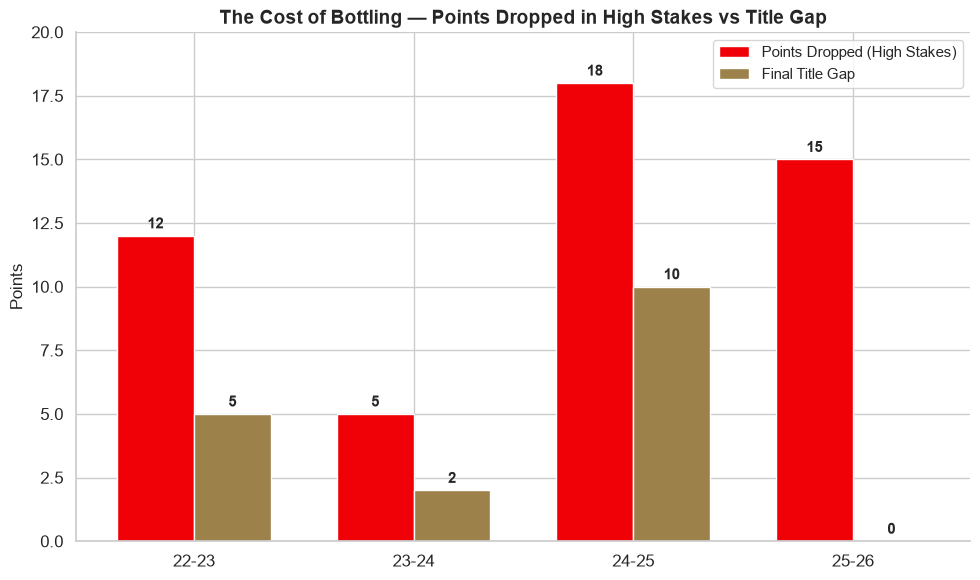

In [37]:
fix, ax = plt.subplots(figsize = (10,6))

x = np.arange(len(cost_df))
width = 0.35

bars_dropped = ax.bar(x - width/2, cost_df['Dropped'], width,
                     label = 'Points Dropped (High Stakes)', color = ARSENAL_RED)
bars_gap = ax.bar(x + width/2, cost_df['Title Gap'], width,
                 label = 'Final Title Gap', color = ARSENAL_GOLD)

ax.bar_label(bars_dropped, padding = 3, fontsize = 11, fontweight= 'bold')
ax.bar_label(bars_gap, padding = 3, fontsize = 11, fontweight= 'bold')

ax.set_xticks(x)
ax.set_xticklabels(cost_df['Season'], fontsize = 12)
ax.set_ylabel('Points', fontsize = 12)
ax.set_title('The Cost of Bottling — Points Dropped in High Stakes vs Title Gap',
             fontsize=14, fontweight='bold')
ax.set_ylim(0,20)
ax.legend(fontsize=11, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## The Killer Matches — Where the Points Were Lost

The bottle isn't 10 bad matches per season. It's **2-3 specific results** that cost exactly the title. Let's identify them.

In [38]:
# The Specific matches that cost Arsenal the title

for szn in [2223,2324,2425,2526]:
    runin = ars[(ars['season'] == szn) & (ars['gameweek'] >=29)]
    hs_runin = runin[runin['is_high_stakes']]
    bad = hs_runin[hs_runin['result'] != 'W']

    label = SEASON_LABELS[szn]
    pts = runin['points'].sum()
    status = 'Champions' if szn == 2526 else f"{ars[(ars['season']==szn) & (ars['gameweek']==38)]['title_gap'].values[0]} pts behind"

    print(f'\n{label} — Run-in: {pts}/30 pts — {status}')
    if len(bad) > 0:
        print(bad[['gameweek', 'opponent', 'scored', 'conceded', 'result',
                    'xG', 'xGA', 'match_drop_index']].to_string(index=False))
    else:
        print('  No dropped points in high-stakes run-in matches')


22-23 — Run-in: 15/30 pts — 5 pts behind
 gameweek        opponent  scored  conceded result       xG     xGA  match_drop_index
       30       Liverpool       2         2      D 1.536310 4.64012          1.964391
       31        West Ham       2         2      D 2.717820 1.96095          0.034051
       32     Southampton       3         3      D 2.396090 1.43063         -0.070244
       33 Manchester City       1         4      L 0.398372 2.01168          1.219140

23-24 — Run-in: 25/30 pts — 2 pts behind
 gameweek        opponent  scored  conceded result       xG      xGA  match_drop_index
       29 Manchester City       0         0      D 0.511402 1.220090          1.046585
       32     Aston Villa       0         2      L 1.890030 0.929049          0.211751

24-25 — Run-in: 19/30 pts — 10 pts behind
 gameweek       opponent  scored  conceded result       xG      xGA  match_drop_index
       31        Everton       1         1      D 1.403100 1.228750          0.354799
       32 

### The crucial detail

Look at the `match_drop_index` column for these dropped results. Many are **negative** — meaning Arsenal *overperformed on xG* in those matches but still didn't win. They created the chances. They just didn't convert.

This is the smoking gun: **the bottle is in conversion, not creation.**

---
# Section D — Act 3: What Changed in 2025-26?

*Three charts. The payoff.*

Arsenal won the title in 2025-26. Given what we've found — that the bottle is about conversion, not creation — the question becomes: **did Arsenal start converting in high-stakes matches?**

---

## Chart D1 - Season Comparison Table (Styled DataFrame) 

In [39]:
comparison_data = []

for szn in[2223,2324,2425,2526]:
    s = ars[ars['season'] == szn]
    hs = s[s['is_high_stakes']]
    runin = s[s['gameweek'] >= 29]

    comparison_data.append({
        'Season':                 SEASON_LABELS[szn],
        'HS xGD (Process)':       hs['xgd'].mean(),
        'HS GD (Outcome)':        hs['gd'].mean(),
        'Bottle Gap':             hs['gd'].mean() - hs['xgd'].mean(),
        'Run-In Pts (of 30)':     runin['points'].sum(),
        'HS Win Rate %':          hs['is_win'].mean() * 100,
        'Total Points':           s['points'].sum(),
    })

comp_df = pd.DataFrame(comparison_data).set_index('Season').round(2)

styled = (
    comp_df.style
    .background_gradient(cmap = 'RdYlGn', subset=['HS xGD (Process)', 'HS GD (Outcome)',
                                                 'Run-In Pts (of 30)', 'HS Win Rate %',
                                                 'Total Points'])
        .background_gradient(cmap='RdYlGn', subset=['Bottle Gap'])  # closer to 0 = greener
    .format('{:.2f}')
    .set_caption('Arsenal Season Comparison — Process vs Outcome')
)

styled


,HS xGD (Process),HS GD (Outcome),Bottle Gap,Run-In Pts (of 30),HS Win Rate %,Total Points
Season,,,,,,
22-23,0.66,1.14,0.49,15.00,64.29,84.00
23-24,1.68,2.53,0.85,25.00,86.67,89.00
24-25,0.54,0.80,0.26,19.00,46.67,74.00
25-26,1.21,1.06,-0.15,24.00,64.71,85.00


---
## Chart D2 — Rolling xG Through the Season (Overlay)



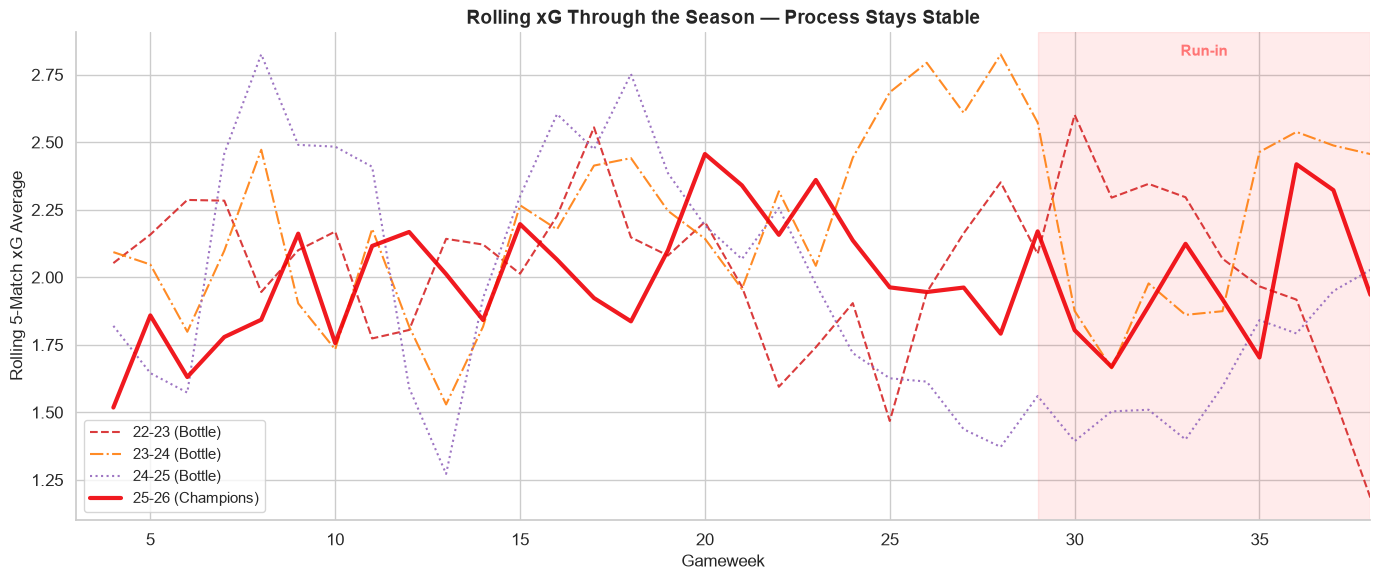

In [40]:
styles = {
    2223: {'color': '#d62728', 'ls': '--',  'label': '22-23 (Bottle)'},
    2324: {'color': '#ff7f0e', 'ls': '-.',  'label': '23-24 (Bottle)'},
    2425: {'color': '#9467bd', 'ls': ':',   'label': '24-25 (Bottle)'},
    2526: {'color': ARSENAL_RED, 'ls': '-',  'label': '25-26 (Champions)'},
}

fig, ax = plt.subplots(figsize=(14, 6))

for szn, style in styles.items():
    szn_df = ars[ars['season'] == szn].sort_values('gameweek')
    lw = 3.0 if szn == 2526 else 1.5
    ax.plot(szn_df['gameweek'], szn_df['xG_roll5'],
            color=style['color'], linestyle=style['ls'],
            linewidth=lw, label=style['label'], alpha=0.9)

ax.axvspan(29, 38, alpha=0.08, color='red')
ax.text(33.5, ax.get_ylim()[1] * 0.97, 'Run-in', ha='center',
        fontsize=11, fontweight='bold', color='red', alpha=0.5)

ax.set_xlabel('Gameweek', fontsize=12)
ax.set_ylabel('Rolling 5-Match xG Average', fontsize=12)
ax.set_title('Rolling xG Through the Season — Process Stays Stable',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=11)
ax.set_xlim(3, 38)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()